## Dagshub/MLFlow initialization

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import dagshub
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

In [6]:
# Init dagshub
dagshub.init(
    repo_owner='lkhiz23',
    repo_name='House-Prices',
    mlflow=True
)
mlflow.set_experiment("house-prices")

Initialized MLflow to track repo "lkhiz23/House-Prices"

Repository lkhiz23/House-Prices initialized!

<Experiment: artifact_location='mlflow-artifacts:/f9e1c8b09b064383930bd71ebfb93255', creation_time=1775695934039, experiment_id='0', last_update_time=1775695934039, lifecycle_stage='active', name='house-prices', tags={}>

## Exploratory Data Analysis (EDA)

In [11]:
# Load data
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(train, test_size=0.2, random_state=42)
print(f"train_df: {train_df.shape}, test_df: {test_df.shape}")

train_df: (1168, 81), test_df: (292, 81)


In [12]:
# Numerical vs Categorical columns
num_cols = train_df.select_dtypes(include='number').columns.tolist()
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

Numeric columns: 38
Categorical columns: 43


In [13]:
# Missing values
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = ((missing / len(train_df)) * 100).round(2)
missing_df = pd.DataFrame({"Missing count": missing, "Missing %": missing_pct})
print(missing_df)

              Missing count  Missing %
PoolQC                 1162      99.49
MiscFeature            1122      96.06
Alley                  1094      93.66
Fence                   935      80.05
MasVnrType              683      58.48
FireplaceQu             547      46.83
LotFrontage             217      18.58
GarageType               64       5.48
GarageYrBlt              64       5.48
GarageFinish             64       5.48
GarageQual               64       5.48
GarageCond               64       5.48
BsmtFinType1             28       2.40
BsmtFinType2             28       2.40
BsmtExposure             28       2.40
BsmtCond                 28       2.40
BsmtQual                 28       2.40
MasVnrArea                6       0.51
Electrical                1       0.09


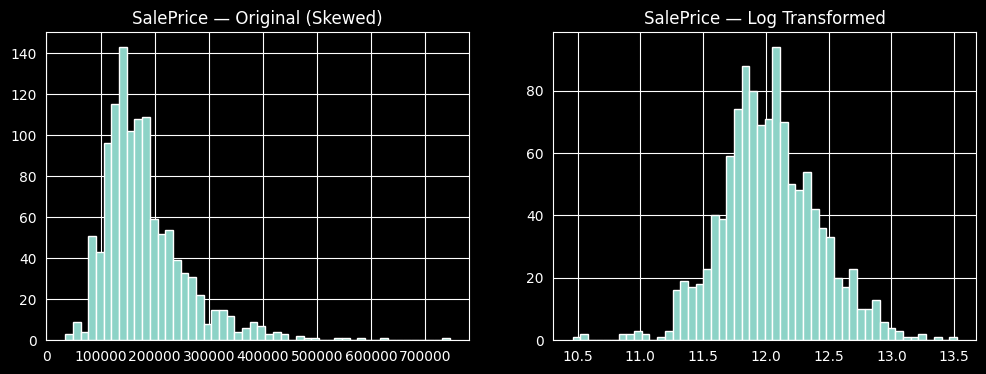

In [14]:
# Target distribution
import os
os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['SalePrice'], bins=50)
axes[0].set_title('SalePrice — Original (Skewed)')
axes[1].hist(np.log1p(train_df['SalePrice']), bins=50)
axes[1].set_title('SalePrice — Log Transformed')
plt.savefig('images/saleprice_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [18]:
# Number of houses in the desired range
total = len(train_df)
print("ფასების განაწილება:")
print(f"< 100k:   {(train_df['SalePrice'] < 100000).sum()} სახლი ({(train_df['SalePrice'] < 100000).sum()/total*100:.1f}%)")
print(f"100-200k: {((train_df['SalePrice'] >= 100000) & (train_df['SalePrice'] < 200000)).sum()} სახლი ({((train_df['SalePrice'] >= 100000) & (train_df['SalePrice'] < 200000)).sum()/total*100:.1f}%)")
print(f"200-300k: {((train_df['SalePrice'] >= 200000) & (train_df['SalePrice'] < 300000)).sum()} სახლი ({((train_df['SalePrice'] >= 200000) & (train_df['SalePrice'] < 300000)).sum()/total*100:.1f}%)")
print(f"300-500k: {((train_df['SalePrice'] >= 300000) & (train_df['SalePrice'] < 500000)).sum()} სახლი ({((train_df['SalePrice'] >= 300000) & (train_df['SalePrice'] < 500000)).sum()/total*100:.1f}%)")
print(f"> 500k:   {(train_df['SalePrice'] >= 500000).sum()} სახლი ({(train_df['SalePrice'] >= 500000).sum()/total*100:.1f}%)")
print(f"> 700k:   {(train_df['SalePrice'] >= 700000).sum()} სახლი ({(train_df['SalePrice'] >= 700000).sum()/total*100:.1f}%)")

ფასების განაწილება:
< 100k:   88 სახლი (7.5%)
100-200k: 727 სახლი (62.2%)
200-300k: 262 სახლი (22.4%)
300-500k: 85 სახლი (7.3%)
> 500k:   6 სახლი (0.5%)
> 700k:   1 სახლი (0.1%)


In [16]:
# სტატისტიკა
print(f"საშუალო:   ${train_df['SalePrice'].mean():,.0f}")
print(f"მედიანა:   ${train_df['SalePrice'].median():,.0f}")
print(f"მაქსიმუმი: ${train_df['SalePrice'].max():,.0f}")
print(f"მინიმუმი:  ${train_df['SalePrice'].min():,.0f}")
print(f"\nSkewness: {train_df['SalePrice'].skew():.4f}")
print(f"Log Skewness: {np.log1p(train_df['SalePrice']).skew():.4f}")

საშუალო:   $181,442
მედიანა:   $165,000
მაქსიმუმი: $745,000
მინიმუმი:  $34,900

Skewness: 1.7431
Log Skewness: 0.1249


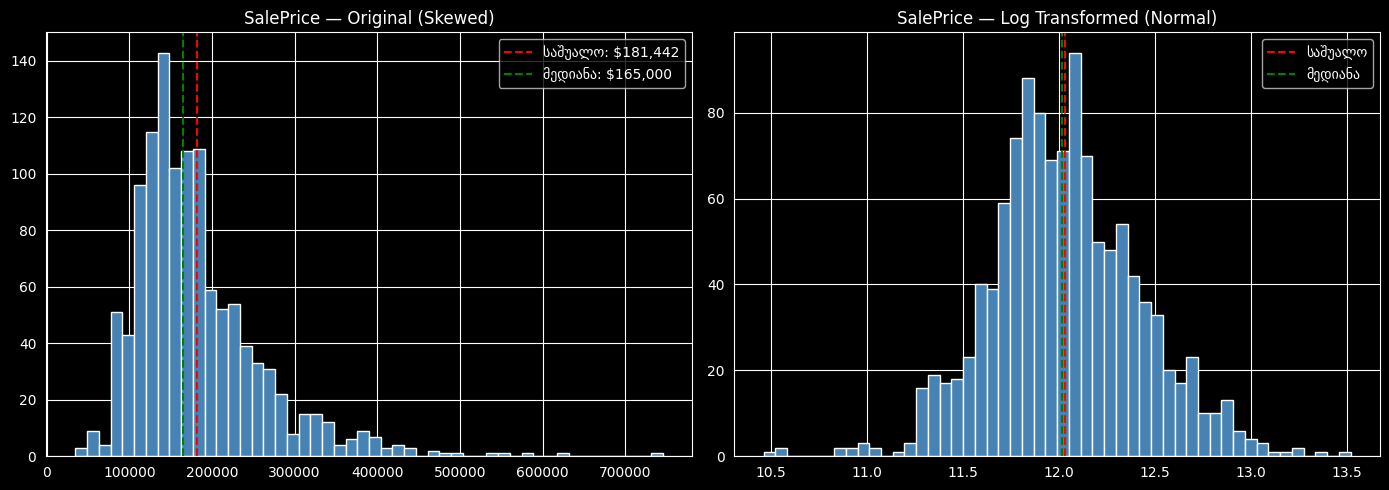

Original  — საშუალო: $181,442 | მედიანა: $165,000
Log       — საშუალო: 12.0307 | მედიანა: 12.0137


In [19]:
# ვიზუალი
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train_df['SalePrice'].mean(), color='red', linestyle='--', label=f"საშუალო: ${train_df['SalePrice'].mean():,.0f}")
axes[0].axvline(train_df['SalePrice'].median(), color='green', linestyle='--', label=f"მედიანა: ${train_df['SalePrice'].median():,.0f}")
axes[0].set_title('SalePrice — Original (Skewed)')
axes[0].legend()

axes[1].hist(np.log1p(train_df['SalePrice']), bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(np.log1p(train_df['SalePrice']).mean(), color='red', linestyle='--', label='საშუალო')
axes[1].axvline(np.log1p(train_df['SalePrice']).median(), color='green', linestyle='--', label='მედიანა')
axes[1].set_title('SalePrice — Log Transformed (Normal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/saleprice_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [25]:
# Correlation with SalePrice
corr = train_df[num_cols].corr()['SalePrice'].sort_values(ascending=False)
print("Top 10:")
print(corr.head(10).round(2))
print("\nBottom 5:")
print(corr.tail(5).round(2))

Top 10:
SalePrice       1.00
OverallQual     0.79
GrLivArea       0.70
GarageCars      0.64
GarageArea      0.62
TotalBsmtSF     0.60
1stFlrSF        0.59
FullBath        0.55
TotRmsAbvGrd    0.52
YearBuilt       0.52
Name: SalePrice, dtype: float64

Bottom 5:
BsmtHalfBath    -0.05
OverallCond     -0.07
MSSubClass      -0.09
KitchenAbvGr    -0.14
EnclosedPorch   -0.15
Name: SalePrice, dtype: float64


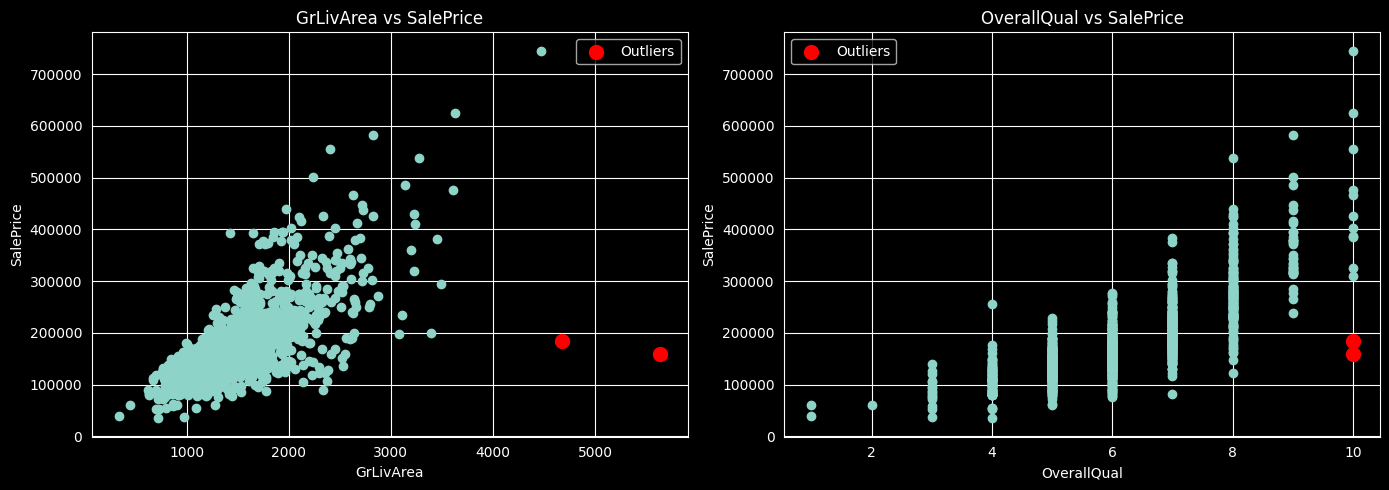

In [39]:
# Outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
normal = train_df.drop(outliers.index)

# GrLivArea plot
axes[0].scatter(normal['GrLivArea'], normal['SalePrice'])
axes[0].scatter(outliers['GrLivArea'], outliers['SalePrice'],
                color='red', s=100, zorder=5, label='Outliers')
axes[0].set_title('GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].legend()

# OverallQual plot
axes[1].scatter(normal['OverallQual'], normal['SalePrice'])
axes[1].scatter(outliers['OverallQual'], outliers['SalePrice'],
                color='red', s=100, zorder=5, label='Outliers')
axes[1].set_title('OverallQual vs SalePrice')
axes[1].set_xlabel('OverallQual')
axes[1].set_ylabel('SalePrice')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/outliers.png', bbox_inches='tight', dpi=150)
plt.show()

In [40]:
# Check if above outliers are the same
outliers_grliv = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
print("GrLivArea outliers:")
print(outliers_grliv[['GrLivArea', 'OverallQual', 'SalePrice']])

GrLivArea outliers:
      GrLivArea  OverallQual  SalePrice
523        4676           10     184750
1298       5642           10     160000


## Data Cleaning

In [46]:
# Target variable — log transform
y = np.log1p(train_df['SalePrice'])
X = train_df.drop('SalePrice', axis=1)

# Test set
y_test_final = np.log1p(test_df['SalePrice'])
X_test_final = test_df.drop('SalePrice', axis=1)

print(f"X shape: {X.shape}")
print(f"X_test shape: {X_test_final.shape}")

X shape: (1168, 80)
X_test shape: (292, 80)


In [47]:
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numeric: {len(numeric_cols)}")
print(f"Categorical: {len(categorical_cols)}")

Numeric: 37
Categorical: 43


In [48]:
# high missing columns
high_missing = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# NaN = "არ აქვს" columns
none_cols = ['FireplaceQu', 'MasVnrType', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2']

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Strategy 1: drop 80%+ missing + median imputation + constant + OHE
drop_cols_s1 = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
X_s1 = X.drop(columns=drop_cols)
X_test_s1 = X_test_final.drop(columns=drop_cols)

num_cols_s1 = X_s1.select_dtypes(include='number').columns.tolist()
cat_cols_s1 = X_s1.select_dtypes(include='object').columns.tolist()

# none_cols in categorical — NaN → "None"
none_cols = ['FireplaceQu', 'MasVnrType', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure',
             'BsmtFinType1', 'BsmtFinType2']

# pipeline
numeric_transformer_s1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s1 = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s1 = ColumnTransformer([
    ('num', numeric_transformer_s1, num_cols_s1),
    ('cat', categorical_transformer_s1, cat_cols_s1)
])

pipeline_s1 = Pipeline([
    ('preprocessor', preprocessor_s1),
    ('model', LinearRegression())
])

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_s1 = cross_val_score(pipeline_s1, X_s1, y,
                         cv=kf,
                         scoring='neg_root_mean_squared_error')
cv_rmse_s1 = -scores_s1.mean()
cv_std_s1 = scores_s1.std()

print(f"Strategy 1 CV RMSE: {cv_rmse_s1:.4f} ± {cv_std_s1:.4f}")

Strategy 1 CV RMSE: 0.1644 ± 0.0240


In [55]:
with mlflow.start_run(run_name="cleaning_s1_drop80_median_ohe"):
    mlflow.log_param("outliers_removed", False)
    mlflow.log_param("drop_threshold", "80%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "None_constant")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse)
    mlflow.log_metric("cv_std", cv_std)

In [56]:
# Strategy 2: drop 45%+ missing + median imputation + most_frequent + OHE
drop_cols_s2 = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']

X_s2 = X.drop(columns=drop_cols_s2)
X_test_s2 = X_test_final.drop(columns=drop_cols_s2)

num_cols_s2 = X_s2.select_dtypes(include='number').columns.tolist()
cat_cols_s2 = X_s2.select_dtypes(include='object').columns.tolist()

numeric_transformer_s2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s2 = ColumnTransformer([
    ('num', numeric_transformer_s2, num_cols_s2),
    ('cat', categorical_transformer_s2, cat_cols_s2)
])

pipeline_s2 = Pipeline([
    ('preprocessor', preprocessor_s2),
    ('model', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_s2 = cross_val_score(pipeline_s2, X_s2, y,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s2 = -scores_s2.mean()
cv_std_s2 = scores_s2.std()

print(f"Strategy 2 CV RMSE: {cv_rmse_s2:.4f} ± {cv_std_s2:.4f}")

Strategy 2 CV RMSE: 0.1624 ± 0.0229


In [57]:
with mlflow.start_run(run_name="cleaning_s2_drop45_median_ohe"):
    mlflow.log_param("outliers_removed", False)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s2)
    mlflow.log_metric("cv_std", cv_std_s2)

In [58]:
# Strategy 3: remove outliers + drop 80%+ missing + median imputation + constant + OHE
outlier_idx = train_df[(train_df['GrLivArea'] > 4000) &
                        (train_df['SalePrice'] < 300000)].index

X_s3 = X.drop(index=outlier_idx).drop(columns=drop_cols)
y_s3 = y.drop(index=outlier_idx)

num_cols_s3 = X_s3.select_dtypes(include='number').columns.tolist()
cat_cols_s3 = X_s3.select_dtypes(include='object').columns.tolist()

numeric_transformer_s3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s3 = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s3 = ColumnTransformer([
    ('num', numeric_transformer_s3, num_cols_s3),
    ('cat', categorical_transformer_s3, cat_cols_s3)
])

pipeline_s3 = Pipeline([
    ('preprocessor', preprocessor_s3),
    ('model', LinearRegression())
])

scores_s3 = cross_val_score(pipeline_s3, X_s3, y_s3,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s3 = -scores_s3.mean()
cv_std_s3 = scores_s3.std()

print(f"Strategy 3 CV RMSE: {cv_rmse_s3:.4f} ± {cv_std_s3:.4f}")

Strategy 3 CV RMSE: 0.1364 ± 0.0149


In [59]:
with mlflow.start_run(run_name="cleaning_s3_drop80_median_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "80%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "None_constant")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s3)
    mlflow.log_metric("cv_std", cv_std_s3)

In [60]:
# Strategy 4: remove outliers + drop 45%+ missing + median imputation + most_frequent + OHE
X_s4 = X.drop(index=outlier_idx).drop(columns=drop_cols_s2)
y_s4 = y.drop(index=outlier_idx)

num_cols_s4 = X_s4.select_dtypes(include='number').columns.tolist()
cat_cols_s4 = X_s4.select_dtypes(include='object').columns.tolist()

numeric_transformer_s4 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s4 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s4 = ColumnTransformer([
    ('num', numeric_transformer_s4, num_cols_s4),
    ('cat', categorical_transformer_s4, cat_cols_s4)
])

pipeline_s4 = Pipeline([
    ('preprocessor', preprocessor_s4),
    ('model', LinearRegression())
])

scores_s4 = cross_val_score(pipeline_s4, X_s4, y_s4,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s4 = -scores_s4.mean()
cv_std_s4 = scores_s4.std()

print(f"Strategy 4 CV RMSE: {cv_rmse_s4:.4f} ± {cv_std_s4:.4f}")

Strategy 4 CV RMSE: 0.1352 ± 0.0158


In [61]:
with mlflow.start_run(run_name="cleaning_s4_drop45_median_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")

    mlflow.log_metric("cv_rmse", cv_rmse_s4)
    mlflow.log_metric("cv_std", cv_std_s4)

In [63]:
# Strategy 5: remove outliers + drop 45%+ + mean imputation + most_frequent + OHE
X_s5 = X.drop(index=outlier_idx).drop(columns=drop_cols_s2)
y_s5 = y.drop(index=outlier_idx)

num_cols_s5 = X_s5.select_dtypes(include='number').columns.tolist()
cat_cols_s5 = X_s5.select_dtypes(include='object').columns.tolist()

numeric_transformer_s5 = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer_s5 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s5 = ColumnTransformer([
    ('num', numeric_transformer_s5, num_cols_s5),
    ('cat', categorical_transformer_s5, cat_cols_s5)
])

pipeline_s5 = Pipeline([
    ('preprocessor', preprocessor_s5),
    ('model', LinearRegression())
])

scores_s5 = cross_val_score(pipeline_s5, X_s5, y_s5,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s5 = -scores_s5.mean()
cv_std_s5 = scores_s5.std()

print(f"Strategy 5 CV RMSE: {cv_rmse_s5:.4f} ± {cv_std_s5:.4f}")

Strategy 5 CV RMSE: 0.1352 ± 0.0158


In [64]:
with mlflow.start_run(run_name="cleaning_s5_drop45_mean_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "mean")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "one_hot")
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("cv_rmse", cv_rmse_s5)
    mlflow.log_metric("cv_std", cv_std_s5)

In [71]:
# Strategy 6: remove outliers + drop 45%+ + median imputation + most_frequent + Full Ordinal + OHE
from sklearn.preprocessing import OrdinalEncoder

X_s6 = X.drop(index=outlier_idx).drop(columns=drop_cols_s2)
y_s6 = y.drop(index=outlier_idx)

# ordinal columns
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond']
ordinal_categories = [['Po', 'Fa', 'TA', 'Gd', 'Ex']] * len(ordinal_cols)

extra_ordinal_cols = ['BsmtExposure', 'GarageFinish', 'Functional', 'Electrical']
extra_ordinal_categories = [
    ['No', 'Mn', 'Av', 'Gd'],
    ['Unf', 'RFn', 'Fin'],
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr']
]

bsmt_fin_cols = ['BsmtFinType1', 'BsmtFinType2']
bsmt_fin_categories = [['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']] * 2

all_ordinal_cols = ordinal_cols + extra_ordinal_cols + bsmt_fin_cols
all_ordinal_categories = ordinal_categories + extra_ordinal_categories + bsmt_fin_categories

# remaining categorical columns
remaining_cat_cols = [col for col in X_s6.select_dtypes(include='object').columns.tolist()
                      if col not in all_ordinal_cols]
num_cols_s6 = X_s6.select_dtypes(include='number').columns.tolist()

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='TA')),
    ('encoder', OrdinalEncoder(categories=all_ordinal_categories,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

numeric_transformer_s6 = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_s6 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s6 = ColumnTransformer([
    ('num', numeric_transformer_s6, num_cols_s6),
    ('ordinal', ordinal_transformer, all_ordinal_cols),
    ('cat', categorical_transformer_s6, remaining_cat_cols)
])

pipeline_s6 = Pipeline([
    ('preprocessor', preprocessor_s6),
    ('model', LinearRegression())
])

scores_s6 = cross_val_score(pipeline_s6, X_s6, y_s6,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')
cv_rmse_s6 = -scores_s6.mean()
cv_std_s6 = scores_s6.std()

print(f"Strategy 6 CV RMSE: {cv_rmse_s6:.4f} ± {cv_std_s6:.4f}")

Strategy 6 CV RMSE: 0.1296 ± 0.0109


In [72]:
with mlflow.start_run(run_name="cleaning_s6_drop45_median_ordinal_ohe_no_outliers"):
    mlflow.log_param("outliers_removed", True)
    mlflow.log_param("drop_threshold", "45%+")
    mlflow.log_param("num_imputation", "median")
    mlflow.log_param("cat_imputation", "most_frequent")
    mlflow.log_param("encoding", "ordinal+ohe")
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_metric("cv_rmse", cv_rmse_s6)
    mlflow.log_metric("cv_std", cv_std_s6)